In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
sns.set_theme(font='monospace', palette='Spectral')

In [8]:
from sktime.datasets.forecasting import Airline
dataset = Airline()
y = dataset.load("y")

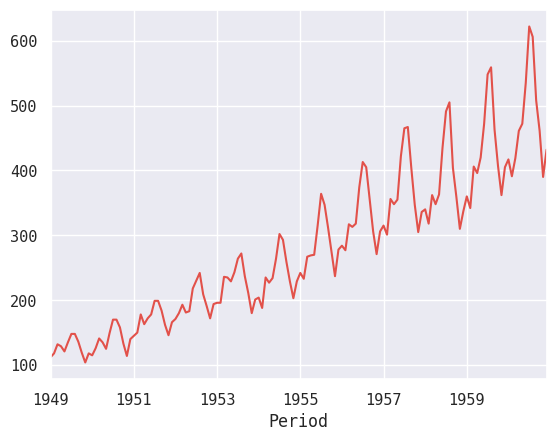

In [9]:
y.plot();

# Is $Forecasting$ = $Regression$?
---

<big>

In a typical regression problem, the usual task is to predict some value $y$ using some a linear combination of features in $X$.

$$y = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \epsilon$$

> When working with time series, some of the most important (and sometimes the *only*) features are the previous, or *lagged*, values of $y$. 

<br>

In [10]:
X = (pd.concat([
    y.shift(i).rename(f"L{i}")
    for i 
    in range(6)
], axis=1)).rename(columns={'L0': 'y'})

In [11]:
X.dropna().head()

,y,L1,L2,L3,L4,L5
Period,,,,,,
1949-06,135.0,121.0,129.0,132.0,118.0,112.0
1949-07,148.0,135.0,121.0,129.0,132.0,118.0
1949-08,148.0,148.0,135.0,121.0,129.0,132.0
1949-09,136.0,148.0,148.0,135.0,121.0,129.0
1949-10,119.0,136.0,148.0,148.0,135.0,121.0


<br>

<big>

### "Manually" regressing `y` on lagged values of itself
---

- First, let's create a dataframe with our lagged values of `y` using the `.shift` method
- We can fit the lagged model using `statsmodels` 

<br>

In [12]:
import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
import statsmodels.api as sm

In [13]:
mod_lagged = smf.ols(
    formula='y ~ trend + L1 + L2 + L3 + L4 + L5',
    data=X.assign(trend=np.arange(len(X)))
)

res_lagged = mod_lagged.fit()
res_lagged.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     404.9
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           2.04e-82
Time:                        20:04:16   Log-Likelihood:                -654.01
No. Observations:                 139   AIC:                             1322.
Df Residuals:                     132   BIC:                             1343.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     45.3516      8.764      5.175      0.000      28.015      62.688
trend          1.4466      0.247      5.853      0.000       0.958       1.935
L1             1.0308      0.089     11.612      0.000       0.855       1.206
L2            -0.4595      0.129     -3.567      0.001      -0.714      -0.205
L3             0.0387      0.137      0.283      0.778      -0.232       0.310
L4            -0.1221      0.132     -0.928      0.355      -0.382       0.138
L5            -0.0235      0.095     -0.249      0.804      -0.211       0.164
==============================================================================
Omnibus:                        1.532   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.465   Jarque-Bera (JB):                1.212
Skew:                           0.222   Prob(JB):                        0.545
Kurtosis:                       3.111   Cond. No.                     2.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<br>

<big>

### Problems with this approach - 1
---

- Our lagged values are highly correlated with each other, our regression suffers from [multicollinearity](https://en.wikipedia.org/wiki/Multicollinearity), and that ruins our estimates of the slopes.

<br>

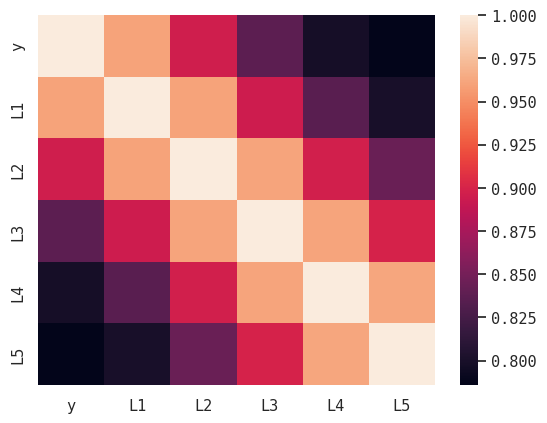

In [14]:
sns.heatmap(X.corr());

<br>

<big>

### Problems with this approach - 2
---

- We intuitively expect the $\beta_i$s to **gradually decline to zero.**
- The immediately preceding period *should* be most important ($\beta_1$ is the largest coefficient in absolute value), followed by $\beta_2$, and $\beta_3$...

- Looking at the regression summary and the bar graph below, this isn't the case

<br>

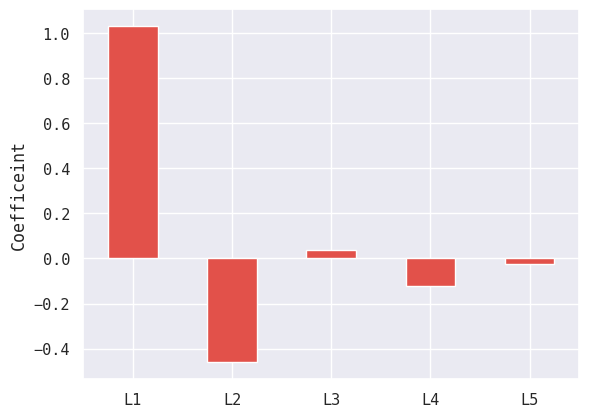

In [15]:
ax = res_lagged.params.drop(['Intercept', 'trend']).plot.bar(rot=0)
ax.set_ylabel('Coefficeint');

<br>

<big>

### Problems with this approach - 3
---

- Another problem our lagged model suffered from is [autocorrelation](https://en.wikipedia.org/wiki/Autocorrelation) (also know as serial correlation).

- Residuals (the observed minus the expected, or $\hat{e_t} = y_t - \hat{y_t}$) are supposed to be [white noise](https://en.wikipedia.org/wiki/White_noise). That's [one of the assumptions](https://en.wikipedia.org/wiki/Gauss–Markov_theorem) many of the properties of linear regression are founded upon.


<br>

<br>

# Time Series Decomposition
---

<big>

Use the `decompose` function to break up the data into

- Trend
- Seasonality
- Residuals

From the charts below, we observe that:

- There is an upwards trend
- There is strong seasonality
- There is a clear **pattern in the residuals** of our regression model

<br>

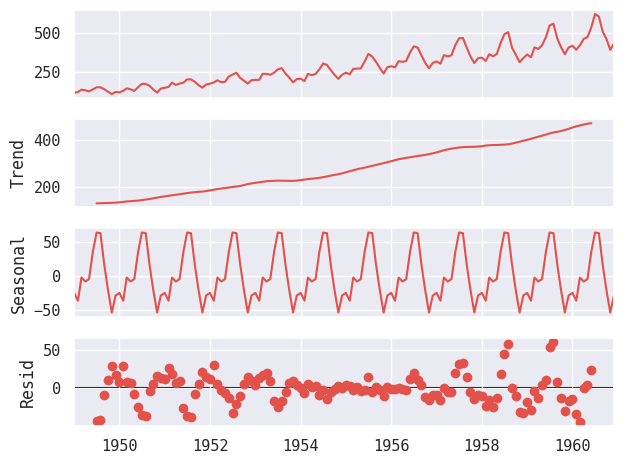

In [16]:
z = pd.Series(data=y.values, index=pd.to_datetime(y.index.to_timestamp()))

smt.seasonal_decompose(z).plot();

<br>

<big>

# Modeling Trend

Let's fit a simple model of $y = \beta_0 + \beta_1 T + \epsilon$, where `T` is the time trend (`np.arange(len(y))`).

<br>

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [18]:
mod_trend = sm.OLS.from_formula(
    data=y.to_frame(name='y').assign(trend=np.arange(len(y))),
    formula='y ~ trend'
)

result_trend = mod_trend.fit()

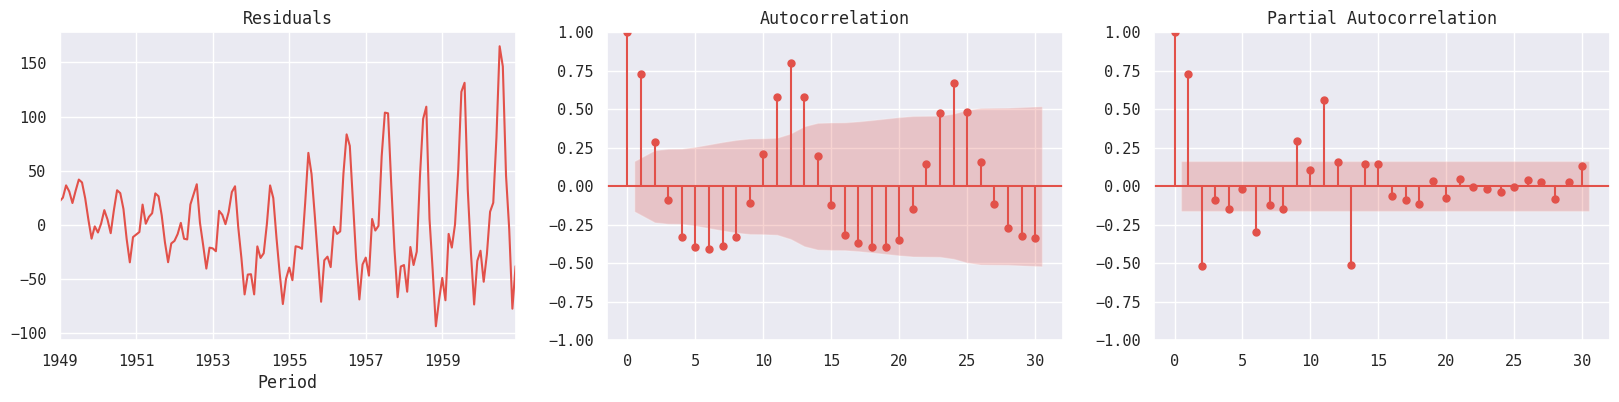

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(20, 4))
result_trend.resid.plot(ax=axs[0], title='Residuals')
plot_acf(result_trend.resid, lags=30, ax=axs[1])
plot_pacf(result_trend.resid, lags=30, ax=axs[2]);

<br>
<big>

**In this case there's a correlation between one residual and the next**: 

If the residual at time $t$ was above expectation, then the residual at time $t + 1$ is *much* more likely to be above average as well ($e_t > 0 \implies E_t[e_{t+1}] > 0$).

- Plot (1) shows the time series of our residuals, which should be white noise (but it isn't).
- Plot (2) shows the autocorrelation of the residuals as a correlogram
- Plot (3) shows the partial autocorrelations. It's partial in the sense that the value for $corr(e_t, e_{t-k})$ is the correlation between those two periods, after controlling for the values at all shorter lags.

<br>

<br>

<big>

### Stationarity
---

Autocorrelation is a problem in regular regressions, but we'll use it to our advantage when we set up an ARIMA model
The basic idea is: 

- If your regression residuals have a clear pattern, then there's some structure in the data that you aren't taking advantage of.
- If a positive residual today means you'll likely have a positive residual tomorrow, why not incorporate that information into your forecast, and lower your forecasted value for tomorrow? That's pretty much what ARIMA does.
- It's important that your dataset be **stationary**, otherwise you run the risk of finding [spurious correlations](http://www.tylervigen.com/spurious-correlations).

> **The typical way to handle non-stationarity is to difference the non-stationary variable until is is stationary.**


<br>

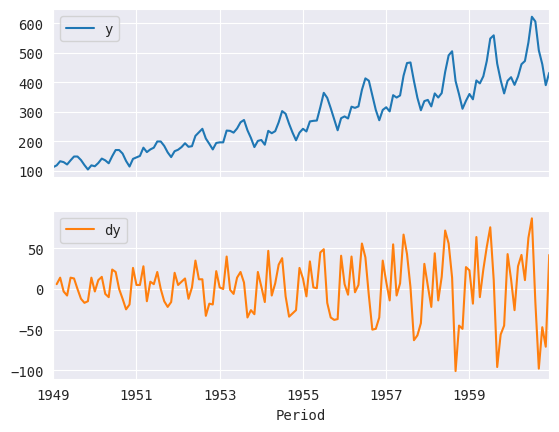

In [51]:
(y
 .to_frame(name='y')
 .assign(dy=lambda x: x.y.diff())
 .plot(subplots=True)
);

<br>

<big>

### Augmented Dickey-Fuller test
---

A more rigorous methods for detecting whether a series is non-stationary.

It's a statistical hypothesis test that roughly says:
- $H_0$ (null hypothesis): $y$ is non-stationary, needs to be differenced
- $H_A$ (alternative hypothesis): $y$ is stationary, doesn't need to be differenced

This is implemented in statsmodels as [`smt.adfuller`](http://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html).


<br>

In [63]:
pd.Series(data=smt.adfuller(y), index="adf pvalue usedlag nobs critical icbest".split())

adf                                                  0.815369
pvalue                                                0.99188
usedlag                                                    13
nobs                                                      130
critical    {'1%': -3.4816817173418295, '5%': -2.884041834...
icbest                                             996.692931
dtype: object

<br>

<big>

We see that 

```python
pvalue = 0.99
```

<br>

- So we failed to reject the null hypothesis that the original series was non-stationary.

Let's difference it.

<br>

In [73]:
differenced_y = y.diff(1).dropna()

pd.Series(data=smt.adfuller(differenced_y), index="adf pvalue usedlag nobs critical icbest".split())

adf                                                 -2.829267
pvalue                                               0.054213
usedlag                                                    12
nobs                                                      130
critical    {'1%': -3.4816817173418295, '5%': -2.884041834...
icbest                                             988.506932
dtype: object

<br>

<big>

Now

```python
pvalue = 0.05
```

<br>

... much better

We'll fit another OLS model of $y = \beta_0 + \beta_1 L \Delta y_{t-1} + e_t$

<br>

In [20]:
data = (y.to_frame(name='y')
         .assign(dy=lambda df: df.y.diff())
         .assign(Ldy=lambda df: df.dy.shift()))

data

,y,dy,Ldy
Period,,,
1949-01,112.0,NaN,NaN
1949-02,118.0,6.0,NaN
1949-03,132.0,14.0,6.0
1949-04,129.0,-3.0,14.0
1949-05,121.0,-8.0,-3.0
...,...,...,...
1960-08,606.0,-16.0,87.0
1960-09,508.0,-98.0,-16.0
1960-10,461.0,-47.0,-98.0


In [21]:
mod_stationary = smf.ols(
    formula='dy ~ Ldy', 
    data=data.dropna()
)

res_stationary = mod_stationary.fit()
res_stationary.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     dy   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     14.29
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           0.000231
Time:                        20:32:25   Log-Likelihood:                -694.29
No. Observations:                 142   AIC:                             1393.
Df Residuals:                     140   BIC:                             1398.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6125      2.722      0.592      0.555      -3.769       6.994
Ldy            0.3059      0.081      3.781      0.000       0.146       0.466
==============================================================================
Omnibus:                        4.293   Durbin-Watson:                   1.838
Prob(Omnibus):                  0.117   Jarque-Bera (JB):                4.593
Skew:                          -0.201   Prob(JB):                        0.101
Kurtosis:                       3.784   Cond. No.                         33.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

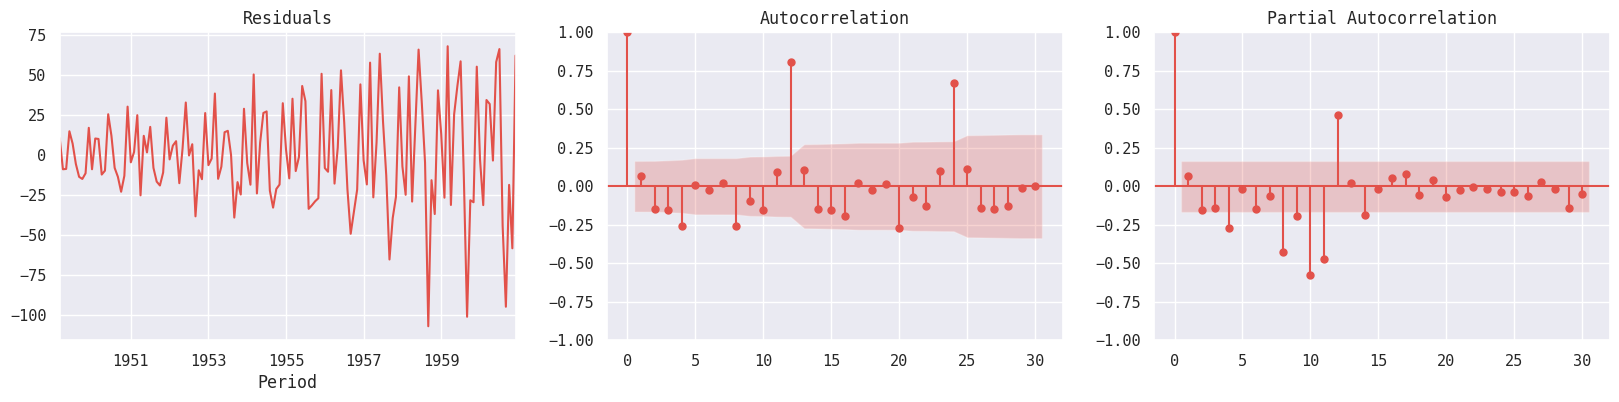

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(20, 4))
res_stationary.resid.plot(ax=axs[0], title='Residuals')
plot_acf(res_stationary.resid, lags=30, ax=axs[1])
plot_pacf(res_stationary.resid, lags=30, ax=axs[2]);

<br>

# ARIMA
---

<big>

So, we've sketched the problems with regular old regression: multicollinearity, autocorrelation, non-stationarity, and seasonality.
Our tool of choice, `smt.SARIMAX`, which stands for Seasonal ARIMA with eXogenous regressors, can handle all these.
We'll walk through the components in pieces.

ARIMA stands for AutoRegressive Integrated Moving Average.
It's a relatively simple yet flexible way of modeling univariate time series.
It's made up of three components, and is typically written as $\mathrm{ARIMA}(p, d, q)$.

ARIMA stands for AutoRegressive Integrated Moving Average, and it's a relatively simple way of modeling univariate time series.
It's made up of three components, and is typically written as $\mathrm{ARIMA}(p, d, q)$.

### [AutoRegressive](https://www.otexts.org/fpp/8/3)
---

The idea is to predict a variable by a linear combination of its lagged values (*auto*-regressive as in regressing a value on its past *self*).
An AR(p), where $p$ represents the number of lagged values used, is written as

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \ldots + \phi_p y_{t-p} + e_t$$

$c$ is a constant and $e_t$ is white noise.
This looks a lot like a linear regression model with multiple predictors, but the predictors happen to be lagged values of $y$ (though they are estimated differently).

<big>

### Integrated
---

Integrated is like the opposite of differencing, and is the part that deals with stationarity.
If you have to difference your dataset 1 time to get it stationary, then $d=1$.
We'll introduce one bit of notation for differencing: $\Delta y_t = y_t - y_{t-1}$ for $d=1$.

<br>

### [Moving Average](https://www.otexts.org/fpp/8/4)
---

MA models look somewhat similar to the AR component, but it's dealing with different values.

$$y_t = c + e_t + \theta_1 e_{t-1} + \theta_2 e_{t-2} + \ldots + \theta_q e_{t-q}$$

$c$ again is a constant and $e_t$ again is white noise.
But now the coefficients are the *residuals* from previous predictions.

<big>

### Combining
---

Putting that together, an ARIMA(1, 1, 1) process is written as

$$\Delta y_t = c + \phi_1 \Delta y_{t-1} + \theta_t e_{t-1} + e_t$$

Using *lag notation*, where $L y_t = y_{t-1}$, i.e. `y.shift()` in pandas, we can rewrite that as

$$(1 - \phi_1 L) (1 - L)y_t = c + (1 + \theta L)e_t$$

That was for our specific $\mathrm{ARIMA}(1, 1, 1)$ model. For the general $\mathrm{ARIMA}(p, d, q)$, that becomes

$$(1 - \phi_1 L - \ldots - \phi_p L^p) (1 - L)^d y_t = c + (1 + \theta L + \ldots + \theta_q L^q)e_t$$

Fortunately, the model is pretty easy to use with statsmodels (using it *correctly*, in a statistical sense, is another matter).

In [23]:
# Building an ARIMA model with trend
mod = smt.SARIMAX(y, trend='c', order=(1, 1, 1))
res = mod.fit()

res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:     Number of airline passengers   No. Observations:                  144
Model:                         SARIMAX(1, 1, 1)   Log Likelihood                -694.060
Date:                          Mon, 17 Nov 2025   AIC                           1396.121
Time:                                  20:36:37   BIC                           1407.972
Sample:                              01-31-1949   HQIC                          1400.937
                                   - 12-31-1960                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.6187      5.001      0.724      0.469      -6.183      13.421
ar.L1         -0.4768      0.128     -3.736      0.000      -0.727      -0.227
ma.L1          0.8646      0.080     10.746      0.000       0.707       1.022
sigma2       958.4115    107.040      8.954      0.000     748.616    1168.207
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 2.17
Prob(Q):                              0.64   Prob(JB):                         0.34
Heteroskedasticity (H):               7.01   Skew:                            -0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

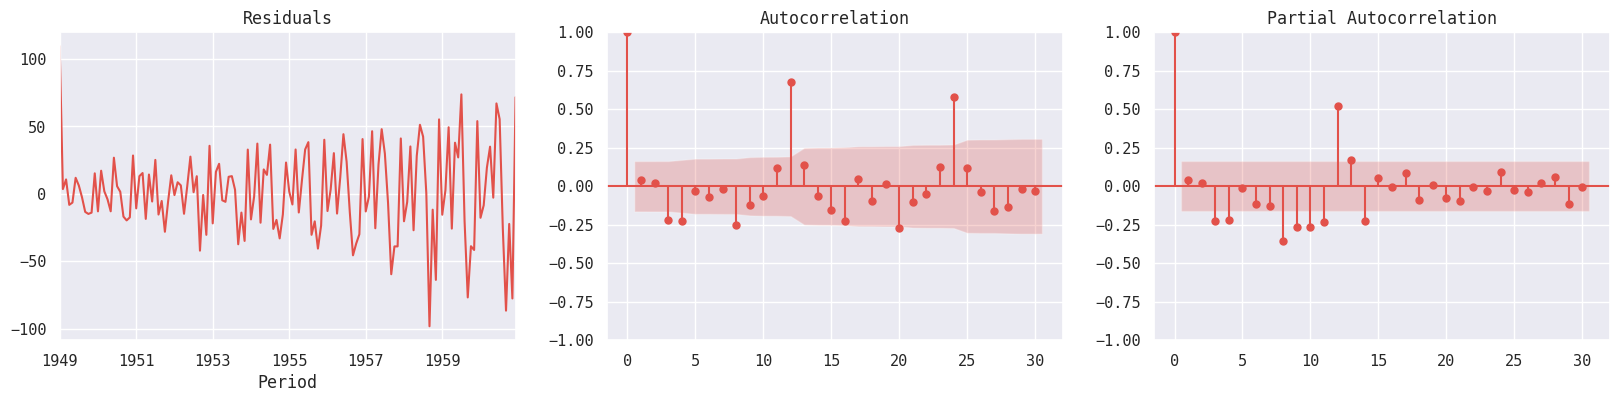

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(20, 4))
res.resid.plot(ax=axs[0], title='Residuals')
plot_acf(res.resid, lags=30, ax=axs[1])
plot_pacf(res.resid, lags=30, ax=axs[2]);

In [25]:
mod_seasonal = smt.SARIMAX(y, trend='c',
                           order=(1, 1, 2), 
                           seasonal_order=(0, 1, 2, 12),
                           simple_differencing=False)
res_seasonal = mod_seasonal.fit()
res_seasonal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:       Number of airline passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 2)x(0, 1, 2, 12)   Log Likelihood                -505.495
Date:                            Mon, 17 Nov 2025   AIC                           1024.989
Time:                                    20:37:03   BIC                           1045.116
Sample:                                01-31-1949   HQIC                          1033.167
                                     - 12-31-1960                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3660      1.078      0.340      0.734      -1.747       2.479
ar.L1         -0.4189      1.214     -0.345      0.730      -2.798       1.960
ma.L1          0.0524      1.234      0.042      0.966      -2.366       2.471
ma.L2         -0.0910      0.467     -0.195      0.845      -1.006       0.824
ma.S.L12      -0.1327      0.104     -1.278      0.201      -0.336       0.071
ma.S.L24       0.1820      0.111      1.644      0.100      -0.035       0.399
sigma2       130.4829     15.539      8.397      0.000     100.027     160.938
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.43
Prob(Q):                              0.96   Prob(JB):                         0.07
Heteroskedasticity (H):               2.70   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

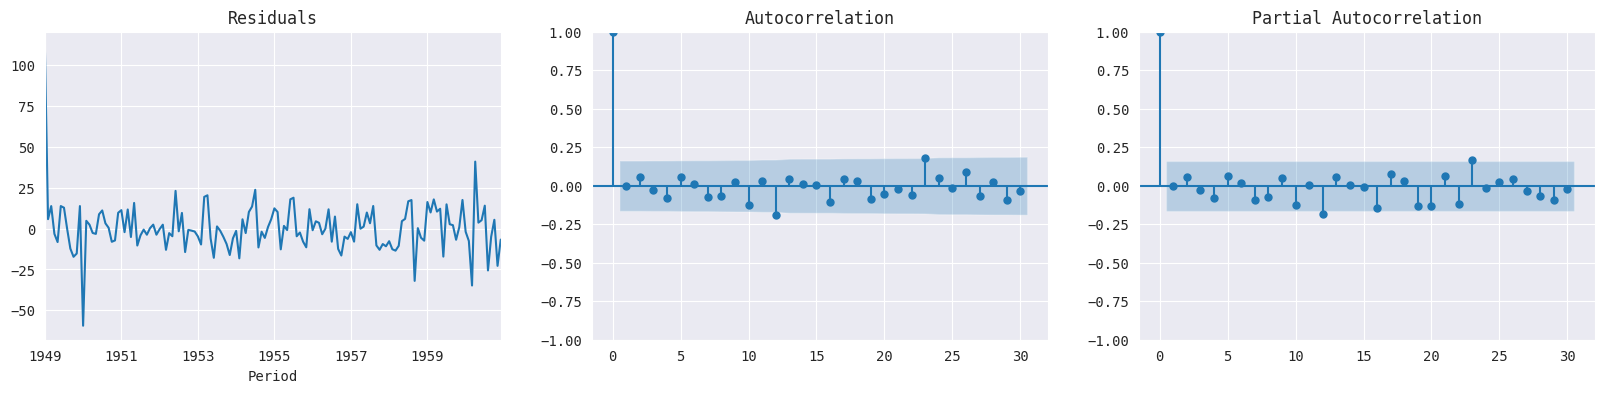

In [113]:
fig, axs = plt.subplots(1, 3, figsize=(20, 4))
res_seasonal.resid.plot(ax=axs[0], title='Residuals')
plot_acf(res_seasonal.resid, lags=30, ax=axs[1])
plot_pacf(res_seasonal.resid, lags=30, ax=axs[2]);

<br>

## Forecasting using the fitted SARIMAX model
---

<big>

- Now that we fit that model, let's put it to use.
- First, we'll make a bunch of **one-step ahead** forecasts.
- At each point (month), we take the history up to that point and make a forecast for the next month.

- So the forecast for January 1957 has available all the data up through December 1956.

<br>

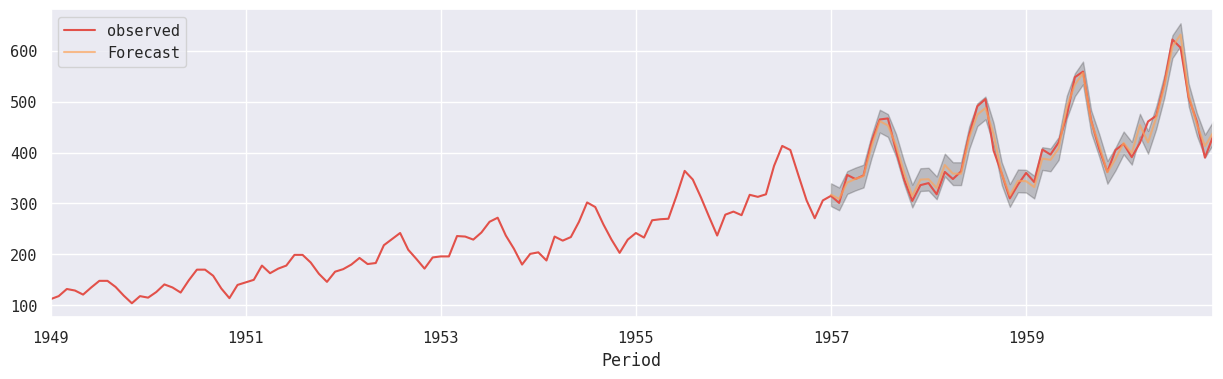

In [26]:
pred = res_seasonal.get_prediction(start='1957-01')
pred_ci = pred.conf_int()

ax = y.plot(label='observed', figsize=(15, 4))
pred.predicted_mean.plot(ax=ax, label='Forecast', alpha=.7)

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)


plt.legend();

<br>

<big>

### Dynamic Forecasts
---

- There are a few places where the observed series slips outside the 95% confidence interval.
- Alternatively, we can make *dynamic* forecasts starting from a certain date.
- That means the forecast from that point forward only use information available as of that date.
- The predictions are generated in a similar way: a bunch of one-step forecasts.

- Only instead of plugging in the *actual* values beyond the date, we plug in the *forecast* values.

<br>

In [27]:
pred_dy = res_seasonal.get_prediction(start='1959-01', dynamic='1961-01')
pred_dy_ci = pred_dy.conf_int()

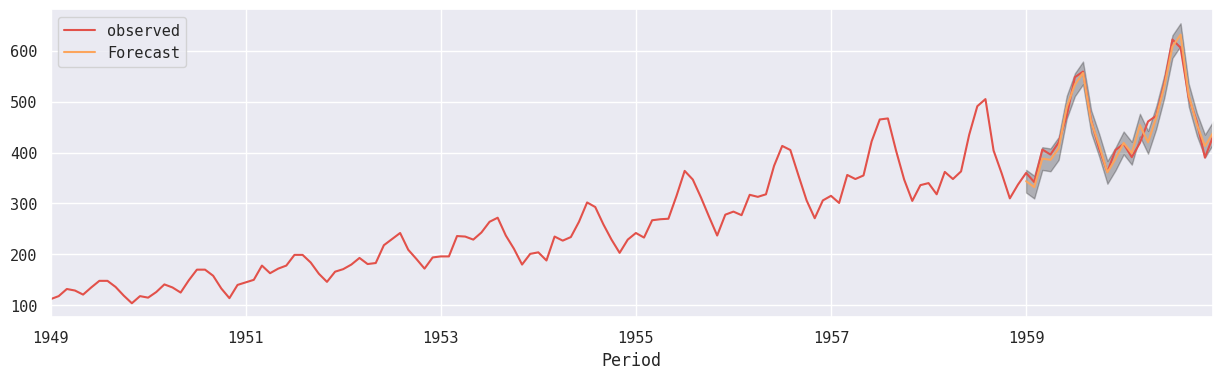

In [28]:
ax = y.plot(label='observed')
pred_dy.predicted_mean.plot(ax=ax, label='Forecast', figsize=(15, 4))
ax.fill_between(pred_dy_ci.index,
                pred_dy_ci.iloc[:, 0],
                pred_dy_ci.iloc[:, 1], color='k', alpha=.25)

plt.legend()